# Batch Generation of Datasets

This notebook demonstrates how to generate multiple FOVs and create complete datasets for training machine learning models or benchmarking analysis methods.

## Contents

1. **Why Batch Generation?** - Use cases and considerations
2. **Basic Batch Loop** - Generating multiple FOVs
3. **Dataset Organization** - Structuring outputs
4. **Reproducibility** - Controlling random seeds
5. **Variation Strategies** - Adding biological/technical variability
6. **Export Formats** - Saving to different file formats
7. **Complete Example** - End-to-end dataset generation

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path
import json
from tqdm import tqdm

from pointillsim import (
    TissueCellTypes,
    CellTypesProperties,
    HybISS_Setup,
    FOVDistribution,
    FrameWideElement,
    VacuolatedStructure,
    HistologicalElement,
    RandomCellTypeRule,
    MixOfNCellTypesRule,
    DistanceBasedRule,
    IdentityTransfer,
)

plt.rcParams['figure.dpi'] = 100
plt.rcParams['figure.facecolor'] = 'white'

---
## 1. Why Batch Generation?

Single FOVs are useful for exploration, but real applications often require **many FOVs**:

### Use Cases

| Application | Typical Dataset Size |
|-------------|---------------------|
| Method benchmarking | 10-100 FOVs |
| ML model training | 100-10,000 FOVs |
| Statistical power analysis | 50-500 FOVs |
| Parameter sensitivity studies | 10-50 per condition |

### Key Considerations

1. **Reproducibility**: Control random seeds for exact replication
2. **Variation**: Model biological and technical variability
3. **Organization**: Structure outputs for easy access
4. **Efficiency**: Balance memory and disk usage

---
## 2. Basic Batch Loop

The simplest approach: iterate and generate multiple FOVs from the same distribution.

In [38]:
# Define shared components
n_cell_types = 4
frame_size = 500

# Create tissue (shared across all FOVs)
tissue = TissueCellTypes()
tissue.generate_types_and_markers(
    n_genes=30,
    n_cell_types=n_cell_types,
    expected_level=8.0,
    concentration=0.85,
)

# Cell properties (shared)
cell_props = CellTypesProperties(n_cell_types=n_cell_types)

# FOV distribution (reusable)
fov_dist = FOVDistribution(
    frame_size=frame_size,
    background_element=lambda: FrameWideElement(
        frame_size=frame_size,
        tipical_cell_spacing=15,
        rules=RandomCellTypeRule(n_cell_types=n_cell_types)
    ),
)

print(f"Tissue: {tissue.n_genes} genes, {tissue.n_cell_types} types")

Tissue: 30 genes, 4 types


In [39]:
# Generate multiple FOVs
n_fovs = 5

fov_list = []
dots_list = []

for i in range(n_fovs):
    # Generate FOV
    fov = fov_dist.generate_fov()
    cell_props.apply(fov)
    
    # Generate observations
    hybiss = HybISS_Setup(tissue)
    hybiss.observe_dots(fov)
    
    # Store results
    fov_list.append(fov)
    dots_list.append(hybiss.make_pandas_df())
    
    print(f"FOV {i}: {fov.n_cells} cells, {len(dots_list[-1])} dots")

FOV 0: 1254 cells, 7871 dots
FOV 1: 1254 cells, 9622 dots
FOV 2: 1254 cells, 9597 dots
FOV 3: 1254 cells, 8379 dots
FOV 4: 1254 cells, 9018 dots


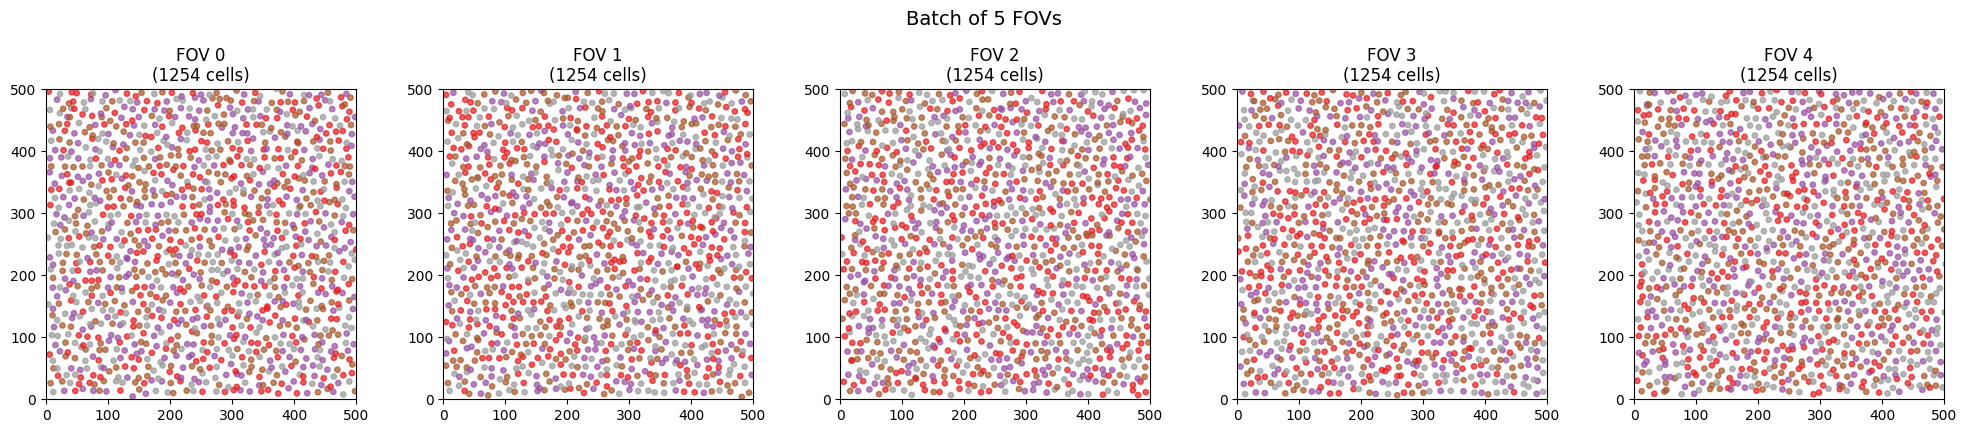

In [4]:
# Visualize batch
fig, axes = plt.subplots(1, n_fovs, figsize=(4*n_fovs, 4))

for i, (ax, fov) in enumerate(zip(axes, fov_list)):
    ax.scatter(
        fov.cell_centroids[:, 0],
        fov.cell_centroids[:, 1],
        c=fov.class_instance,
        cmap='Set1',
        s=15, alpha=0.7
    )
    ax.set_xlim(0, frame_size)
    ax.set_ylim(0, frame_size)
    ax.set_aspect('equal')
    ax.set_title(f'FOV {i}\n({fov.n_cells} cells)')

plt.suptitle('Batch of 5 FOVs', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

Each FOV is an independent sample from the same generative process. Notice how:
- Cell counts vary slightly
- Spatial patterns differ
- Cell type proportions fluctuate around the same mean

This natural variation is important for training robust models.

---
## 3. Dataset Organization

For larger datasets, we need a structured approach to storing results.

### Option A: Single DataFrame with FOV identifiers

In [5]:
# Combine all dots with FOV identifier
all_dots = []
all_cells = []

for i, (fov, dots_df) in enumerate(zip(fov_list, dots_list)):
    # Add FOV identifier to dots
    dots_with_id = dots_df.copy()
    dots_with_id['fov_id'] = i
    all_dots.append(dots_with_id)
    
    # Add FOV identifier to cells
    cells_df = fov.make_pandas_df()
    cells_df['fov_id'] = i
    all_cells.append(cells_df)

# Concatenate
combined_dots = pd.concat(all_dots, ignore_index=True)
combined_cells = pd.concat(all_cells, ignore_index=True)

print(f"Combined dots DataFrame: {combined_dots.shape}")
print(f"Combined cells DataFrame: {combined_cells.shape}")
print(f"\nDots per FOV:")
print(combined_dots.groupby('fov_id').size())

Combined dots DataFrame: (51452, 5)
Combined cells DataFrame: (6270, 17)

Dots per FOV:
fov_id
0     9863
1    10152
2    11356
3     9749
4    10332
dtype: int64


### Option B: Hierarchical storage (HDF5 or NPZ)

For very large datasets, storing each FOV separately with a unified index is more memory-efficient.

In [6]:
def save_dataset_npz(output_dir, fov_list, dots_list, tissue):
    """Save dataset in NPZ format with metadata."""
    output_dir = Path(output_dir)
    output_dir.mkdir(exist_ok=True)
    
    # Save tissue reference
    np.savez(
        output_dir / 'tissue.npz',
        gene_expression=tissue.gene_expression_by_type,
        n_cell_types=tissue.n_cell_types,
        n_genes=tissue.n_genes,
    )
    
    # Save each FOV
    for i, (fov, dots_df) in enumerate(zip(fov_list, dots_list)):
        np.savez(
            output_dir / f'fov_{i:04d}.npz',
            cell_centroids=fov.cell_centroids,
            cell_probabilities=fov.cell_probabilities,
            class_instance=fov.class_instance,
            dot_x=dots_df['x'].values,
            dot_y=dots_df['y'].values,
            dot_gene=dots_df['gene'].values,
            dot_cell=dots_df['cell'].values,
        )
    
    # Save metadata
    metadata = {
        'n_fovs': len(fov_list),
        'frame_size': fov_list[0].frame_size if hasattr(fov_list[0], 'frame_size') else None,
        'n_cell_types': tissue.n_cell_types,
        'n_genes': tissue.n_genes,
    }
    with open(output_dir / 'metadata.json', 'w') as f:
        json.dump(metadata, f, indent=2)
    
    print(f"Saved dataset to {output_dir}")
    return output_dir

# Example (commented out to avoid creating files)
# save_dataset_npz('/tmp/my_dataset', fov_list, dots_list, tissue)

---
## 4. Reproducibility

Controlling random seeds ensures exact replication of results.

### Per-FOV Seeds

Assign a unique seed to each FOV for reproducibility while maintaining variation.

In [31]:
def generate_reproducible_batch(n_fovs, base_seed=42):
    """Generate a batch of FOVs with reproducible seeds."""
    results = []
    
    for i in range(n_fovs):
        # Set seed for this FOV
        np.random.seed(base_seed + i)
        
        # Generate FOV
        fov = fov_dist.generate_fov()
        cell_props.apply(fov)
        
        results.append({
            'fov_id': i,
            'seed': base_seed + i,
            'n_cells': fov.n_cells,
            'fov': fov,
        })
    
    return results

# Generate twice with same base seed - should get identical results
batch1 = generate_reproducible_batch(3, base_seed=123)
batch2 = generate_reproducible_batch(3, base_seed=123)

print("First batch:")
for r in batch1:
    print(f"  FOV {r['fov_id']}: {r['n_cells']} cells")

print("\nSecond batch (should match):")
for r in batch2:
    print(f"  FOV {r['fov_id']}: {r['n_cells']} cells")

# Verify they're identical
for r1, r2 in zip(batch1, batch2):
    assert r1['n_cells'] == r2['n_cells']
    assert np.allclose(r1['fov'].cell_centroids, r2['fov'].cell_centroids)
print("\n✓ Batches are identical!")

First batch:
  FOV 0: 1254 cells
  FOV 1: 1254 cells
  FOV 2: 1254 cells

Second batch (should match):
  FOV 0: 1254 cells
  FOV 1: 1254 cells
  FOV 2: 1254 cells

✓ Batches are identical!


### Recording Seeds for Reproducibility

Always save the seeds used for dataset generation.

In [32]:
# Generate batch with recorded seeds
generation_log = []

for i in range(5):
    seed = 1000 + i * 7  # Any deterministic scheme
    np.random.seed(seed)
    
    fov = fov_dist.generate_fov()
    
    generation_log.append({
        'fov_id': i,
        'seed': seed,
        'n_cells': fov.n_cells,
        'mean_prob_entropy': float(-np.sum(
            fov.cell_probabilities * np.log2(fov.cell_probabilities + 1e-10),
            axis=1
        ).mean()),
    })

# Save log
log_df = pd.DataFrame(generation_log)
print("Generation Log:")
print(log_df.to_string(index=False))

Generation Log:
 fov_id  seed  n_cells  mean_prob_entropy
      0  1000     1254           1.570261
      1  1007     1254           1.569153
      2  1014     1254           1.566419
      3  1021     1254           1.570388
      4  1028     1254           1.565270


---
## 5. Variation Strategies

Real datasets exhibit variation at multiple levels. Here's how to model each.

### 5.1 Biological Variation

Vary tissue composition across FOVs to simulate samples from different patients or conditions.

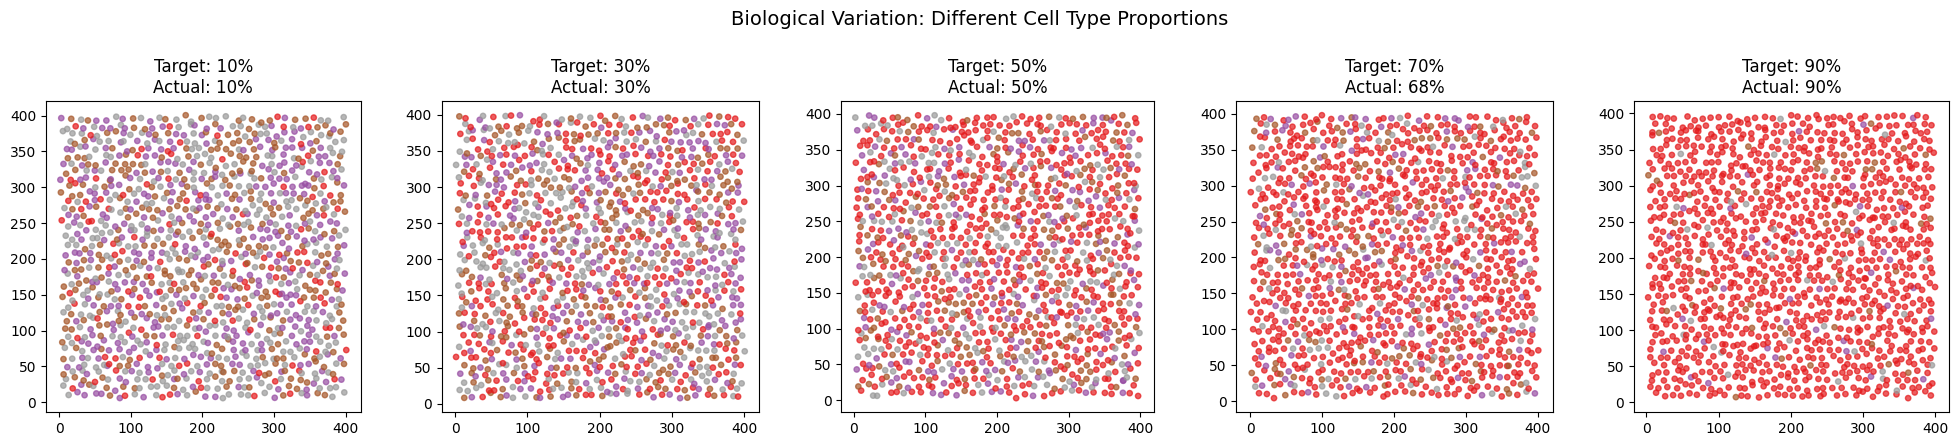

In [34]:
# Generate FOVs with varying cell type proportions
def make_variable_fov(proportion_type0, seed=None):
    """Create FOV with variable type proportions."""
    if seed is not None:
        np.random.seed(seed)
    
    # Remaining proportion split among other types
    remaining = 1.0 - proportion_type0
    other_props = [remaining / 3] * 3  # Split equally
    
    fov_dist_var = FOVDistribution(
        frame_size=400,
        background_element=lambda: FrameWideElement(
            frame_size=400,
            tipical_cell_spacing=12,
            rules=MixOfNCellTypesRule(
                n_cell_types=4,
                list_N=[0, 1, 2, 3],
                proportions=[proportion_type0] + other_props
            )
        ),
    )
    
    return fov_dist_var.generate_fov()

# Generate FOVs with varying proportions
proportions = [0.1, 0.3, 0.5, 0.7, 0.9]
variable_fovs = [make_variable_fov(p, seed=42+i) for i, p in enumerate(proportions)]

# Visualize
fig, axes = plt.subplots(1, 5, figsize=(20, 4))

for ax, fov, prop in zip(axes, variable_fovs, proportions):
    ax.scatter(
        fov.cell_centroids[:, 0],
        fov.cell_centroids[:, 1],
        c=fov.class_instance,
        cmap='Set1',
        vmin=0, vmax=3,
        s=15, alpha=0.7
    )
    ax.set_aspect('equal')
    
    # Count actual proportions
    actual = (fov.class_instance == 0).sum() / fov.n_cells
    ax.set_title(f'Target: {prop:.0%}\nActual: {actual:.0%}')

plt.suptitle('Biological Variation: Different Cell Type Proportions', fontsize=14, y=1.05)
plt.tight_layout()
plt.show()

### 5.2 Technical Variation

Model differences in imaging conditions, detection efficiency, etc.

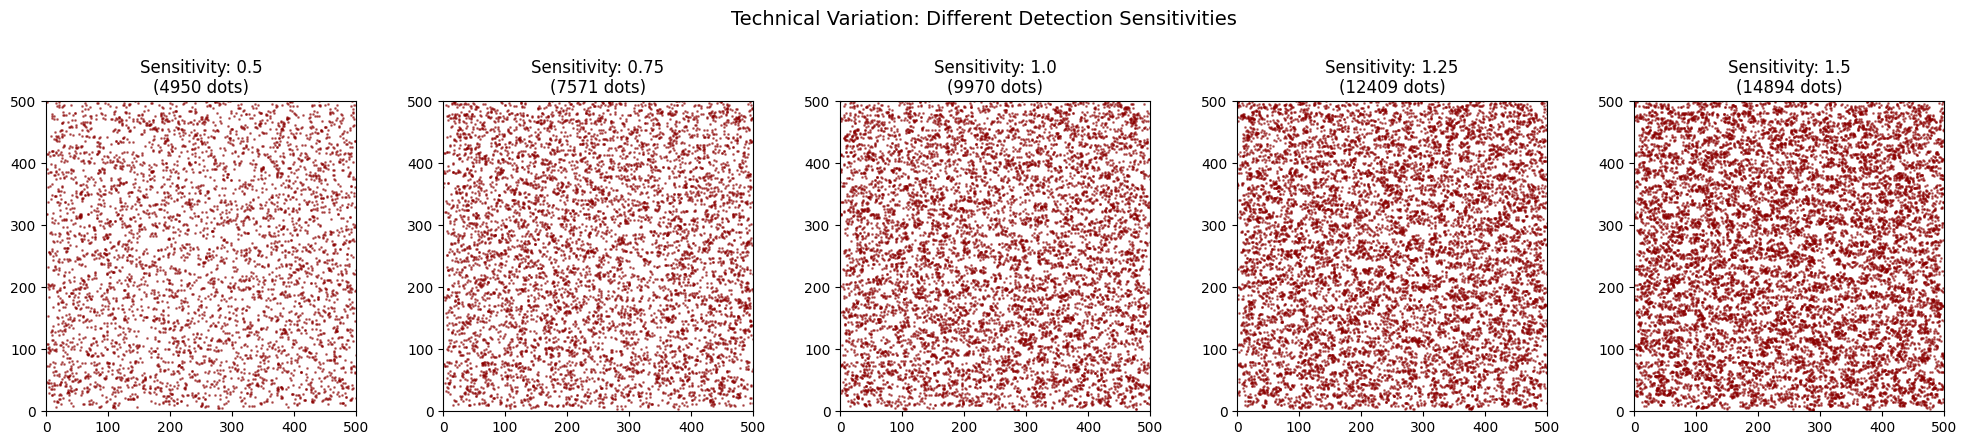

In [35]:
# Generate FOVs with varying detection sensitivity
sensitivities = [0.5, 0.75, 1.0, 1.25, 1.5]
np.random.seed(42)

fig, axes = plt.subplots(1, 5, figsize=(20, 4))

for ax, sensitivity in zip(axes, sensitivities):
    # Use same FOV
    np.random.seed(42)
    fov = fov_dist.generate_fov()
    cell_props.apply(fov)
    
    # Different sensitivity
    hybiss = HybISS_Setup(
        tissue=tissue,
        genes_sensitivities=sensitivity,
        genes_sensitivities_variation=0.1,
    )
    hybiss.observe_dots(fov)
    dots_df = hybiss.make_pandas_df()
    
    ax.scatter(dots_df['x'], dots_df['y'], s=1, alpha=0.5, c='darkred')
    ax.set_xlim(0, 500)
    ax.set_ylim(0, 500)
    ax.set_aspect('equal')
    ax.set_title(f'Sensitivity: {sensitivity}\n({len(dots_df)} dots)')

plt.suptitle('Technical Variation: Different Detection Sensitivities', fontsize=14, y=1.05)
plt.tight_layout()
plt.show()

### 5.3 Structural Variation

Vary the number and types of structures present.

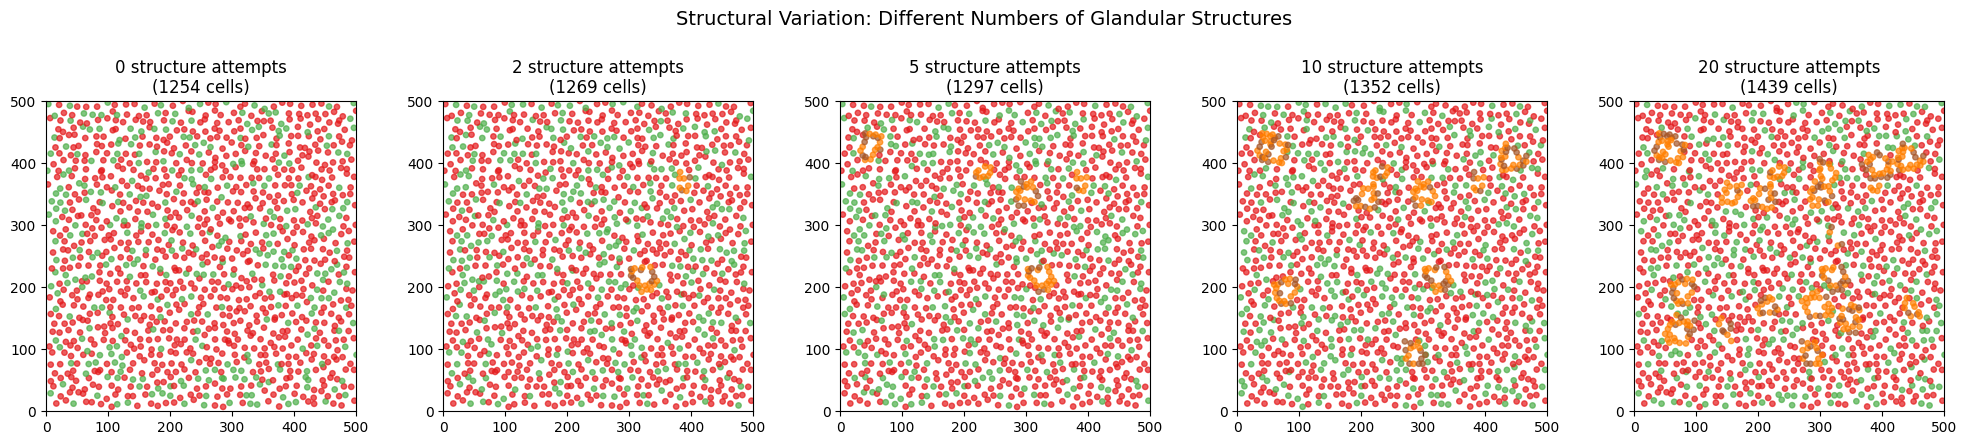

In [36]:
# FOV distribution with variable structure placement
n_cell_types = 5
frame_size = 500

def make_structural_fov_dist(n_structures):
    """Create FOV distribution with specified structure attempts."""
    return FOVDistribution(
        frame_size=frame_size,
        background_element=lambda: FrameWideElement(
            frame_size=frame_size,
            tipical_cell_spacing=15,
            rules=MixOfNCellTypesRule(
                n_cell_types=n_cell_types,
                list_N=[0, 1],
                proportions=[0.7, 0.3]
            )
        ),
        other_elements=[
            lambda: VacuolatedStructure(
                frame_size=frame_size,
                scale=60,
                hole_scale_factor=0.5,
                tipical_cell_spacing=8,
                rules=DistanceBasedRule(
                    n_cell_types=n_cell_types,
                    inner_type=2,
                    outer_type=3,
                )
            )
        ],
        elements_frequency=[1.0],
        attempts_at_elements=n_structures,
    )

# Generate FOVs with different structure counts
structure_counts = [0, 2, 5, 10, 20]

fig, axes = plt.subplots(1, 5, figsize=(20, 4))

for ax, n_struct in zip(axes, structure_counts):
    np.random.seed(42)
    fov_dist_struct = make_structural_fov_dist(n_struct)
    fov = fov_dist_struct.generate_fov()
    
    ax.scatter(
        fov.cell_centroids[:, 0],
        fov.cell_centroids[:, 1],
        c=fov.class_instance,
        cmap='Set1',
        vmin=0, vmax=4,
        s=15, alpha=0.7
    )
    ax.set_xlim(0, frame_size)
    ax.set_ylim(0, frame_size)
    ax.set_aspect('equal')
    ax.set_title(f'{n_struct} structure attempts\n({fov.n_cells} cells)')

plt.suptitle('Structural Variation: Different Numbers of Glandular Structures', fontsize=14, y=1.05)
plt.tight_layout()
plt.show()

---
## 6. Export Formats

PointillSim supports multiple output formats for different workflows.

### 6.1 Pandas DataFrames (CSV/Parquet)

In [40]:
# Generate a sample FOV
np.random.seed(42)
fov = fov_dist.generate_fov()
cell_props.apply(fov)

hybiss = HybISS_Setup(tissue)
hybiss.observe_dots(fov)

# Export to DataFrames
cells_df = fov.make_pandas_df()
dots_df = hybiss.make_pandas_df()

print("Cells DataFrame:")
print(cells_df.head())
print(f"\nShape: {cells_df.shape}")

# To save:
# cells_df.to_csv('cells.csv', index=False)
# cells_df.to_parquet('cells.parquet', index=False)  # More efficient

Cells DataFrame:
           X          Y  Class ID  Class 0  Class 1  Class 2  Class 3  \
0  16.490142  12.575588         3        0        0        0        1   
1  31.943066  17.559471         1        0        1        0        0   
2  44.297540  12.287970         2        0        0        1        0   
3  64.737638  15.292685         2        0        0        1        0   
4  73.591577  14.618061         2        0        0        1        0   

   ProbClass0  ProbClass1  ProbClass2  ProbClass3  Minor Axis  Major Axis  \
0    0.105132    0.103988    0.419996    0.370884   11.759445   16.136840   
1    0.058690    0.391018    0.487175    0.063117   10.550387   14.837704   
2    0.072161    0.116166    0.467031    0.344642   11.856319   11.670724   
3    0.051228    0.236115    0.381559    0.331098   12.780468   15.768412   
4    0.042068    0.382160    0.220571    0.355201   11.235536   14.573781   

   Rotation  RNA Concentration  \
0  5.887026           0.949366   
1  2.370344  

### 6.2 AnnData Format

For integration with scanpy and single-cell analysis tools.

In [42]:
# Export to AnnData
try:
    adata = fov.to_anndata()
    
    print(f"AnnData object:")
    print(f"  Cells (obs): {adata.n_obs}")
    print(f"  Genes (var): {adata.n_vars}")
    print(f"\nObservation columns:")
    print(f"  {list(adata.obs.columns)}")
    print(f"\nLayers: {list(adata.layers.keys())}")
    print(f"\nSpatial coordinates in: obsm['spatial']")
    
    # To save:
    # adata.write_h5ad('fov.h5ad')
except ImportError:
    print("Install anndata for AnnData export: pip install anndata")

AnnData object:
  Cells (obs): 1254
  Genes (var): 4

Observation columns:
  ['cell_id', 'class_id', 'minor_axis', 'major_axis', 'rotation', 'rna_concentration']

Layers: []

Spatial coordinates in: obsm['spatial']


### 6.3 SpatialData Format

For integration with the spatialdata ecosystem.

In [43]:
# Export to SpatialData
try:
    from pointillsim import fov_to_spatialdata
    
    sdata = fov_to_spatialdata(fov, tissue, dots_df=dots_df)
    
    print(f"SpatialData object:")
    print(f"  Tables: {list(sdata.tables.keys())}")
    print(f"  Points: {list(sdata.points.keys())}")
    print(f"  Shapes: {list(sdata.shapes.keys())}")
    
    # To save:
    # sdata.write('fov.zarr')
except ImportError:
    print("Install spatialdata for SpatialData export: pip install spatialdata")

Install spatialdata for SpatialData export: pip install spatialdata


---
## 7. Complete Example: Training Dataset

Let's put it all together to generate a complete dataset for training.

In [44]:
def generate_training_dataset(
    n_fovs: int,
    n_genes: int = 50,
    n_cell_types: int = 5,
    frame_size: int = 600,
    base_seed: int = 42,
    include_structures: bool = True,
):
    """Generate a complete training dataset.
    
    Returns:
        dict with 'tissue', 'fovs', 'all_cells', 'all_dots', 'metadata'
    """
    # 1. Create tissue
    np.random.seed(base_seed)
    tissue = TissueCellTypes()
    tissue.generate_types_and_markers(
        n_genes=n_genes,
        n_cell_types=n_cell_types,
        expected_level=10.0,
        concentration=0.85,
    )
    
    # 2. Cell properties
    cell_props = CellTypesProperties(n_cell_types=n_cell_types)
    
    # 3. FOV distribution
    if include_structures:
        fov_dist = FOVDistribution(
            frame_size=frame_size,
            background_element=lambda: FrameWideElement(
                frame_size=frame_size,
                tipical_cell_spacing=15,
                rules=MixOfNCellTypesRule(
                    n_cell_types=n_cell_types,
                    list_N=[0, 1],
                    proportions=[0.6, 0.4]
                )
            ),
            other_elements=[
                lambda: VacuolatedStructure(
                    frame_size=frame_size,
                    scale=70,
                    hole_scale_factor=0.5,
                    tipical_cell_spacing=10,
                    rules=DistanceBasedRule(
                        n_cell_types=n_cell_types,
                        inner_type=2,
                        outer_type=3,
                    )
                ),
                lambda: HistologicalElement(
                    frame_size=frame_size,
                    scale=50,
                    tipical_cell_spacing=8,
                    rules=MixOfNCellTypesRule(
                        n_cell_types=n_cell_types,
                        list_N=[4],
                        proportions=[1.0]
                    )
                ),
            ],
            elements_frequency=[0.6, 0.4],
            attempts_at_elements=[3, 2],
        )
    else:
        fov_dist = FOVDistribution(
            frame_size=frame_size,
            background_element=lambda: FrameWideElement(
                frame_size=frame_size,
                tipical_cell_spacing=15,
                rules=RandomCellTypeRule(n_cell_types=n_cell_types)
            ),
        )
    
    # 4. Generate FOVs
    all_cells = []
    all_dots = []
    fovs = []
    
    for i in tqdm(range(n_fovs), desc="Generating FOVs"):
        # Set seed for reproducibility
        np.random.seed(base_seed + i + 1000)
        
        # Generate FOV
        fov = fov_dist.generate_fov()
        cell_props.apply(fov)
        
        # Generate observations
        hybiss = HybISS_Setup(
            tissue=tissue,
            genes_sensitivities=1.0,
            genes_sensitivities_variation=0.2,
        )
        hybiss.observe_dots(fov)
        
        # Collect results
        fovs.append(fov)
        
        cells_df = fov.make_pandas_df()
        cells_df['fov_id'] = i
        all_cells.append(cells_df)
        
        dots_df = hybiss.make_pandas_df()
        dots_df['fov_id'] = i
        all_dots.append(dots_df)
    
    # Combine
    combined_cells = pd.concat(all_cells, ignore_index=True)
    combined_dots = pd.concat(all_dots, ignore_index=True)
    
    # Metadata
    metadata = {
        'n_fovs': n_fovs,
        'n_genes': n_genes,
        'n_cell_types': n_cell_types,
        'frame_size': frame_size,
        'base_seed': base_seed,
        'include_structures': include_structures,
        'total_cells': len(combined_cells),
        'total_dots': len(combined_dots),
    }
    
    return {
        'tissue': tissue,
        'fovs': fovs,
        'all_cells': combined_cells,
        'all_dots': combined_dots,
        'metadata': metadata,
    }

In [45]:
# Generate a small training dataset
dataset = generate_training_dataset(
    n_fovs=10,
    n_genes=40,
    n_cell_types=5,
    frame_size=500,
    base_seed=42,
    include_structures=True,
)

print("\nDataset Summary:")
print(f"  FOVs: {dataset['metadata']['n_fovs']}")
print(f"  Total cells: {dataset['metadata']['total_cells']}")
print(f"  Total dots: {dataset['metadata']['total_dots']}")
print(f"  Genes: {dataset['metadata']['n_genes']}")
print(f"  Cell types: {dataset['metadata']['n_cell_types']}")

Generating FOVs: 100%|██████████| 10/10 [00:01<00:00,  7.54it/s]


Dataset Summary:
  FOVs: 10
  Total cells: 12741
  Total dots: 116751
  Genes: 40
  Cell types: 5


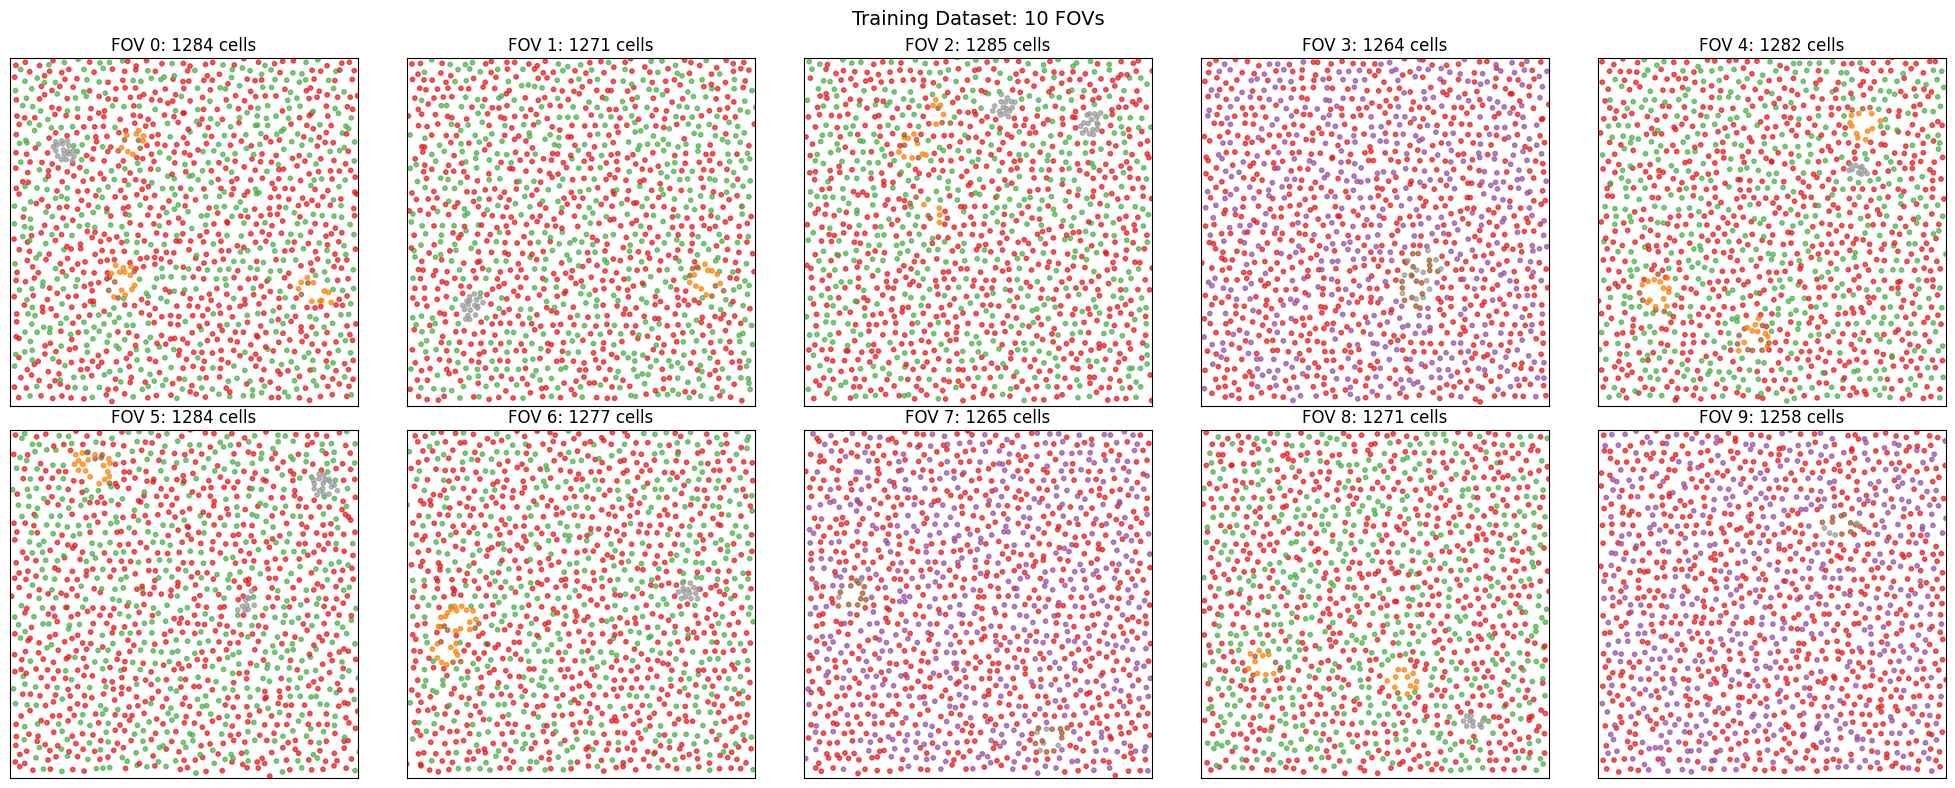

In [46]:
# Visualize sample FOVs
fig, axes = plt.subplots(2, 5, figsize=(20, 8))

for i, (ax, fov) in enumerate(zip(axes.flat, dataset['fovs'])):
    ax.scatter(
        fov.cell_centroids[:, 0],
        fov.cell_centroids[:, 1],
        c=fov.class_instance,
        cmap='Set1',
        s=10, alpha=0.7
    )
    ax.set_xlim(0, 500)
    ax.set_ylim(0, 500)
    ax.set_aspect('equal')
    ax.set_title(f'FOV {i}: {fov.n_cells} cells')
    ax.set_xticks([])
    ax.set_yticks([])

plt.suptitle('Training Dataset: 10 FOVs', fontsize=14)
plt.tight_layout()
plt.show()

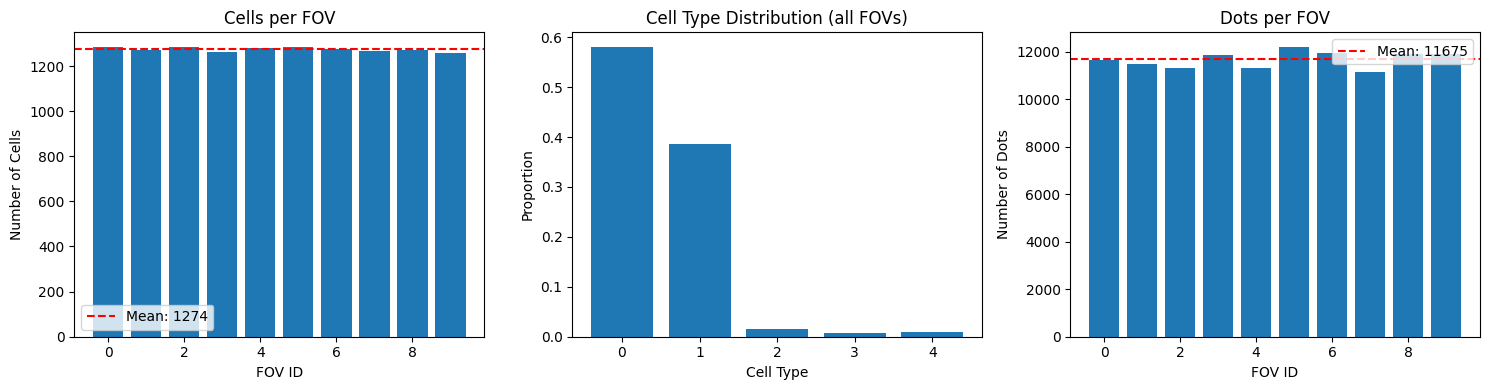

In [47]:
# Dataset statistics
cells_df = dataset['all_cells']

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Cells per FOV
ax = axes[0]
cells_per_fov = cells_df.groupby('fov_id').size()
ax.bar(cells_per_fov.index, cells_per_fov.values)
ax.axhline(cells_per_fov.mean(), color='red', linestyle='--', label=f'Mean: {cells_per_fov.mean():.0f}')
ax.set_xlabel('FOV ID')
ax.set_ylabel('Number of Cells')
ax.set_title('Cells per FOV')
ax.legend()

# Cell type distribution
ax = axes[1]
type_counts = cells_df['Class ID'].value_counts().sort_index()
ax.bar(type_counts.index, type_counts.values / len(cells_df))
ax.set_xlabel('Cell Type')
ax.set_ylabel('Proportion')
ax.set_title('Cell Type Distribution (all FOVs)')

# Dots per FOV
ax = axes[2]
dots_df = dataset['all_dots']
dots_per_fov = dots_df.groupby('fov_id').size()
ax.bar(dots_per_fov.index, dots_per_fov.values)
ax.axhline(dots_per_fov.mean(), color='red', linestyle='--', label=f'Mean: {dots_per_fov.mean():.0f}')
ax.set_xlabel('FOV ID')
ax.set_ylabel('Number of Dots')
ax.set_title('Dots per FOV')
ax.legend()

plt.tight_layout()
plt.show()

---
## Summary

This notebook covered:

| Topic | Key Points |
|-------|------------|
| **Basic Batch Loop** | Iterate and store FOV + dots lists |
| **Organization** | Add FOV identifiers, concatenate DataFrames |
| **Reproducibility** | Per-FOV seeds, generation logs |
| **Variation** | Biological (composition), technical (sensitivity), structural |
| **Export** | CSV, Parquet, AnnData, SpatialData |

### Best Practices

1. **Always set seeds** for reproducibility
2. **Log generation parameters** for each FOV
3. **Use Parquet or HDF5** for large datasets (more efficient than CSV)
4. **Include variation** to train robust models
5. **Verify statistics** match expectations before using

### Next Steps

- **04_real_expression_data.ipynb**: Using real scRNA-seq data as input
- **05_cell_type_rules.ipynb**: Deep dive into all available rules
- **06_tissue_simulations.ipynb**: Simulating specific real tissues